## GSAT trend patterns

In [1]:
# In[1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# %%
# define function
import src.SAT_function as data_process
import src.Data_Preprocess as preprocess

In [2]:
import src.slurm_cluster as scluster
client, scluster = scluster.init_dask_slurm_cluster()

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /scratch/m/m301036/dask_logs//dask-worker-%J.err
#SBATCH -o /scratch/m/m301036/dask_logs//dask-worker-%J.out
#SBATCH -p compute
#SBATCH -A mh0033
#SBATCH -n 1
#SBATCH --cpus-per-task=4
#SBATCH --mem=256G
#SBATCH -t 02:00:00

/home/m/m301036/.conda/envs/mykernel/bin/python -m distributed.cli.dask_worker tcp://136.172.120.135:45343 --nthreads 1 --nworkers 4 --memory-limit 64.00GiB --name dummy-name --nanny --death-timeout 60 --local-directory /scratch/m/m301036/dask_temp/ --interface ib0



In [3]:
dir_in ='/work/mh0033/m301036/Land_surf_temp/Disentangling_OBS_SAT_trend/Supp_Figure1_Forced/data/'
MMEM_annual_ensemble_mean = xr.open_mfdataset(dir_in + 'MMEM_annual_ano_ensemble_mean_1950_2022.nc',chunks={'lat': 10, 'lon': 10})

In [4]:
MMEM_annual_ensemble_mean

<xarray.Dataset>
Dimensions:  (lon: 180, lat: 90, year: 73)
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * year     (year) int64 1950 1951 1952 1953 1954 ... 2018 2019 2020 2021 2022
    height   float64 ...
Data variables:
    tas      (year, lat, lon) float32 dask.array<chunksize=(73, 10, 10), meta=np.ndarray>

In [3]:
# Input the MMEM annual mean SAT data
input_model = '/work/mh0033/m301036/Land_surf_temp/Disentangling_OBS_SAT_trend/Datafiles/'

CanESM_data   = xr.open_mfdataset(input_model + 'tas_CanESM5_annual_ano_1850_2022.nc',chunks = {'run':1})
IPSL_data     = xr.open_mfdataset(input_model + 'tas_IPSL_annual_ano_1850_2022.nc',chunks = {'run':1})
EC_Earth_data = xr.open_mfdataset(input_model + 'tas_EC_Earth_annual_ano_1850_2022.nc',chunks = {'run':1})
ACCESS_data   = xr.open_mfdataset(input_model + 'tas_ACCESS_annual_ano_1850_2022.nc',chunks = {'run':1})
MPI_ESM_data  = xr.open_mfdataset(input_model + 'tas_MPI_ESM_annual_ano_1850_2022.nc',chunks = {'run':1})
MIROC_data    = xr.open_mfdataset(input_model + 'tas_MIROC6_annual_ano_1850_2022.nc',chunks = {'run':1})
# MMEM_annual_data = xr.open_mfdataset(input_model + 'tas_MMEM_annual_anomalies_ds.nc',chunks = {'lat':10,'lon':10})

In [4]:
# Extreact each SMILEs 1950-2022 data then output the ensemble mean anomalies
CanESM_ano = CanESM_data.tas.sel(year=slice('1950','2022')).squeeze()
IPSL_ano = IPSL_data.tas.sel(year=slice('1950','2022')).squeeze()
EC_Earth_ano = EC_Earth_data.tas.sel(year=slice('1950','2022')).squeeze()
ACCESS_ano = ACCESS_data.tas.sel(year=slice('1950','2022')).squeeze()
MPI_ESM_ano = MPI_ESM_data.tas.sel(year=slice('1950','2022')).squeeze()
MIROC_ano = MIROC_data.tas.sel(year=slice('1950','2022')).squeeze()

In [5]:
CanESM_ano_mean = CanESM_ano.mean(dim='run')
IPSL_ano_mean = IPSL_ano.mean(dim='run')
EC_Earth_ano_mean = EC_Earth_ano.mean(dim='run')
ACCESS_ano_mean = ACCESS_ano.mean(dim='run')
MPI_ESM_ano_mean = MPI_ESM_ano.mean(dim='run')
MIROC_ano_mean = MIROC_ano.mean(dim='run')

In [6]:
CanESM_ano_mean

<xarray.DataArray 'tas' (year: 73, lat: 90, lon: 180)>
dask.array<mean_agg-aggregate, shape=(73, 90, 180), dtype=float32, chunksize=(73, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * year     (year) int64 1950 1951 1952 1953 1954 ... 2018 2019 2020 2021 2022
    height   float64 ...

In [7]:
dir_output ='/work/mh0033/m301036/Land_surf_temp/Disentangling_OBS_SAT_trend/Supp_Figure1_Forced/data/'
CanESM_ano_mean.to_netcdf(dir_output + 'CanESM5_annual_ano_ensemble_mean_1950_2022.nc')
IPSL_ano_mean.to_netcdf(dir_output + 'IPSL_annual_ano_ensemble_mean_1950_2022.nc')
EC_Earth_ano_mean.to_netcdf(dir_output + 'EC_Earth_annual_ano_ensemble_mean_1950_2022.nc')
ACCESS_ano_mean.to_netcdf(dir_output + 'ACCESS_annual_ano_ensemble_mean_1950_2022.nc')
MPI_ESM_ano_mean.to_netcdf(dir_output + 'MPI_ESM_annual_ano_ensemble_mean_1950_2022.nc')
MIROC_ano_mean.to_netcdf(dir_output + 'MIROC6_annual_ano_ensemble_mean_1950_2022.nc')

In [8]:
# Concatenate the data
MMEM_annual_data = xr.concat([CanESM_data,IPSL_data,EC_Earth_data,ACCESS_data,MPI_ESM_data,MIROC_data],dim='run')

In [9]:
MMEM_annual_ensemble_mean = MMEM_annual_data.sel(year=slice(1950,2022)).mean(dim='run')

In [10]:
MMEM_annual_ensemble_mean

<xarray.Dataset>
Dimensions:  (lon: 180, lat: 90, year: 73)
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * year     (year) int64 1950 1951 1952 1953 1954 ... 2018 2019 2020 2021 2022
    height   float64 2.0
Data variables:
    tas      (year, lat, lon) float32 dask.array<chunksize=(73, 90, 180), meta=np.ndarray>

In [11]:
# # output the data
# dir_output ='/work/mh0033/m301036/Land_surf_temp/Disentangling_OBS_SAT_trend/Supp_Figure1_Forced/data/'
MMEM_annual_ensemble_mean.to_netcdf(dir_output + 'MMEM_annual_ano_ensemble_mean_1950_2022.nc')

### Calculate the 1950-20222 Model-ENS simulated trend patterns

In [5]:
# separate the data into two sets: Pre-1950 and Post-1950
"""
    Calcualte the trend pattern for the forced variability on each grid point for the consective intervals starting from 
    1940-1949, 1935-1949, 1930-1949, 1925-1949, 1920-1949, 1915-1949, 1910-1949, 1905-1949, 1900-1949, 1895-1949, 1890-1949, 1885-1949, 
    1880-1949, 1875-1949, 1870-1949, 1865-1949, 1860-1949, 1855-1949, 1850-1949
    Put the data segemnet into the same dataset
"""
time_interval = {
    "10yr":(2013,2022),
    "20yr":(2003,2022),
    "30yr":(1993,2022),
    "40yr":(1983,2022),
    "50yr":(1973,2022),
    "60yr":(1963,2022),
    "70yr":(1953,2022)
}
start_year = 1950
end_year   = 2022

In [6]:
# define the function to calculate the trend pattern for the forced variability on each grid point for the consective intervals
variable_name = ['10yr', '20yr', '30yr', '40yr', '50yr', '60yr', '70yr']
# define the function
def separate_data_into_intervals(data, start_year, end_year, time_interval):
    """
    This function is used to separate the data into different time intervals
    """
    # create a dictionary to store the data
    data_dict = {}
    for i in range(len(variable_name)):
        # calculate the start year and end year
        start_year = time_interval[variable_name[i]][0]
        end_year = time_interval[variable_name[i]][1]
        # select the data
        data_dict[variable_name[i]] = data.sel(year=slice(str(start_year), str(end_year)))
    return data_dict

In [7]:
MMEM_annual_tas_dict = separate_data_into_intervals(MMEM_annual_ensemble_mean['tas'], start_year, end_year, time_interval)
MMEM_annual_tas_dict['10yr']

<xarray.DataArray 'tas' (year: 10, lat: 90, lon: 180)>
dask.array<getitem, shape=(10, 90, 180), dtype=float32, chunksize=(10, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * year     (year) int64 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
    height   float64 ...

In [8]:
MMEM_annual_tas_trend = {}
MMEM_annual_tas_p_value = {}

for i in range(len(variable_name)):
    data_var = MMEM_annual_tas_dict[variable_name[i]]
#     print(data_var)
    slope, p_values= xr.apply_ufunc(
        data_process.apply_mannkendall,
        data_var,
        input_core_dims=[["year"]],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    MMEM_annual_tas_trend[variable_name[i]] = slope
    MMEM_annual_tas_p_value[variable_name[i]] = p_values

In [9]:
MMEM_annual_tas_trend_numpy = {}
MMEM_annual_tas_p_value_numpy = {}

for i in range(len(variable_name)):
    MMEM_annual_tas_trend_numpy[variable_name[i]] = MMEM_annual_tas_trend[variable_name[i]].values
    MMEM_annual_tas_p_value_numpy[variable_name[i]] = MMEM_annual_tas_p_value[variable_name[i]].values
    
MMEM_annual_tas_trend_numpy, MMEM_annual_tas_p_value_numpy

({'10yr': array([[0.03809029, 0.03798605, 0.03841229, ..., 0.03737757, 0.03779498,
          0.0380536 ],
         [0.03424097, 0.03391622, 0.0337702 , ..., 0.03506865, 0.03476073,
          0.03434716],
         [0.0320335 , 0.03273046, 0.03372702, ..., 0.03259059, 0.03365447,
          0.0348801 ],
         ...,
         [0.11847715, 0.1195977 , 0.12045002, ..., 0.11665694, 0.1172425 ,
          0.11765838],
         [0.11871982, 0.119138  , 0.11982856, ..., 0.11694506, 0.11761975,
          0.11856246],
         [0.11717673, 0.11729475, 0.11755347, ..., 0.11719427, 0.11716539,
          0.1173776 ]]),
  '20yr': array([[0.03109262, 0.03103104, 0.03118407, ..., 0.03056358, 0.03075818,
          0.03078798],
         [0.02969482, 0.02992497, 0.03016198, ..., 0.02947448, 0.02932167,
          0.02958374],
         [0.03121727, 0.03154268, 0.03151523, ..., 0.03025385, 0.0308023 ,
          0.03123104],
         ...,
         [0.09285794, 0.09325918, 0.09372209, ..., 0.09151562, 0.0916557

In [10]:
MMEM_annual_tas_trend.items()

dict_items([('10yr', <xarray.DataArray 'tas' (lat: 90, lon: 180)>
dask.array<transpose, shape=(90, 180), dtype=float64, chunksize=(10, 10), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
    height   float64 ...), ('20yr', <xarray.DataArray 'tas' (lat: 90, lon: 180)>
dask.array<transpose, shape=(90, 180), dtype=float64, chunksize=(10, 10), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
    height   float64 ...), ('30yr', <xarray.DataArray 'tas' (lat: 90, lon: 180)>
dask.array<transpose, shape=(90, 180), dtype=float64, chunksize=(10, 10), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.

In [11]:
MMEM_annual_tas_trend_da = {}

for interval, data in MMEM_annual_tas_trend.items():
    MMEM_annual_tas_trend_da[interval] = xr.DataArray(MMEM_annual_tas_trend_numpy[interval], 
                                                              dims = ['lat','lon'], 
                                                              coords = {'lat':MMEM_annual_tas_dict[variable_name[i]].lat.values, 
                                                                        'lon':MMEM_annual_tas_dict[variable_name[i]].lon.values})

In [12]:
MMEM_annual_tas_p_value_da = {}

for interval, data in MMEM_annual_tas_p_value.items():
    MMEM_annual_tas_p_value_da[interval] = xr.DataArray(MMEM_annual_tas_p_value_numpy[interval], 
                                                              dims = ['lat','lon'], 
                                                              coords = {'lat':MMEM_annual_tas_dict[variable_name[i]].lat.values, 
                                                                        'lon':MMEM_annual_tas_dict[variable_name[i]].lon.values})

In [13]:
# save the data into netcdf file
dir_output = '/work/mh0033/m301036/Land_surf_temp/Disentangling_OBS_SAT_trend/Supp_Figure1_Forced/data/Smiles_ensemble/'
for interval, data in MMEM_annual_tas_trend_da.items():
    data.to_netcdf(dir_output + 'MMEM_annual_forced_' + interval + '_trend.nc')
    
for interval, data in MMEM_annual_tas_p_value.items():
    data.to_netcdf(dir_output + 'MMEM_annual_forced_' + interval + '_p_value.nc')

In [14]:
# Check min, max of the trend data
for i in range(len(variable_name)):
    print(variable_name[i], MMEM_annual_tas_trend_da[variable_name[i]].min(), MMEM_annual_tas_trend_da[variable_name[i]].max())

10yr <xarray.DataArray ()>
array(-0.00200695) <xarray.DataArray ()>
array(0.22363941)
20yr <xarray.DataArray ()>
array(0.00447132) <xarray.DataArray ()>
array(0.18546789)
30yr <xarray.DataArray ()>
array(0.00699536) <xarray.DataArray ()>
array(0.19315046)
40yr <xarray.DataArray ()>
array(0.00563035) <xarray.DataArray ()>
array(0.17087995)
50yr <xarray.DataArray ()>
array(0.00270122) <xarray.DataArray ()>
array(0.15446086)
60yr <xarray.DataArray ()>
array(0.00144495) <xarray.DataArray ()>
array(0.13034528)
70yr <xarray.DataArray ()>
array(0.00110533) <xarray.DataArray ()>
array(0.10118897)


### Plotting with the Robinson Projections

In [15]:
plt.rcParams['figure.figsize'] = (8, 10)
plt.rcParams['font.size'] = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap

def plot_trend_with_significance(trend_data, lats, lons, p_values, GMST_p_values=None, levels=None, extend=None,cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - trend_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """

    # Create a new figure/axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 15), subplot_kw={'projection': ccrs.Robinson()})
        ax.set_global()
  
    # Determine significance mask (where p-values are less than 0.05)
    insignificance_mask = p_values >= 0.05
    
    # Plotting
    # contour_obj = ax.pcolormesh(lons, lats, trend_data,  cmap='RdBu_r',vmin=-5.0, vmax=5.0, transform=ccrs.PlateCarree(central_longitude=180), shading='auto')
    contour_obj = ax.contourf(lons, lats, trend_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree(central_longitude=0))

    # Plot significance masks with different hatches
    ax.contourf(lons, lats, insignificance_mask, levels=[0,0.05, 1.0],hatches=[None,'///'], colors='none', transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.35, linestyle='--')

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    ax.set_title(title, loc='center', fontsize=18, pad=5.0)

    return contour_obj


In [16]:
# define an asymmetric colormap
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

# intervals = [-0.2, -0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1.1, 1.3]
intervals = [-0.1, -0.075, -0.05, -0.025, 0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75]

# Normalizing the intervals to [0, 1]
min_interval = min(intervals)
max_interval = max(intervals)
normalized_intervals = [(val - min_interval) / (max_interval - min_interval) for val in intervals]

# cmap = mcolors.ListedColormap(palettable.scientific.diverging.Vik_20.mpl_colors)
cmap=mcolors.ListedColormap(palettable.cmocean.diverging.Balance_20.mpl_colors)

# Define the colors at each interval
colors = [(0.00784313725490196, 0.2, 0.4627450980392157, 1.0),
    (0.00784313725490196, 0.2, 0.4627450980392157, 1.0),
    (0.023529411764705882, 0.32941176470588235, 0.5450980392156862, 1.0),
    (0.023529411764705882, 0.32941176470588235, 0.5450980392156862, 1.0),
    (1.0, 1.0, 1.0, 1.0),
    (1.0, 0.9, 0.98, 1.0),
    (1.0, 0.8, 0.5, 1.0),
    (1.0, 0.803921568627451, 0.607843137254902, 1.0), 
    (1.0, 0.6000000000000001, 0.20000000000000018, 1.0),
    (1.0, 0.4039215686274509, 0.0, 1.0),
    (0.8999999999999999, 0.19999999999999996, 0.0, 1.0),
    (0.7470588235294118, 0.0, 0.0, 1.0), 
    (0.6000000000000001, 0.0, 0.0, 1.0),
    (0.44705882352941173, 0.0, 0.0, 1.0),
    (0.30000000000000004, 0.0, 0.0, 1.0),
    (0.14705882352941177, 0.0, 0.0, 1.0),
    (0.0, 0.0, 0.0, 1.0)]

# Creating a list of tuples with normalized positions and corresponding colors
color_list = list(zip(normalized_intervals, colors))

# Create the colormap
custom_cmap = LinearSegmentedColormap.from_list('my_custom_cmap', color_list)

# Create a normalization
norm = Normalize(vmin=min_interval, vmax=max_interval)

### Plot the Original, Forced, MMEM trend patterns

In [17]:
# transform the trend data unit to degree per decade
for i in range(len(variable_name)):
    MMEM_annual_tas_trend_da[variable_name[i]] = MMEM_annual_tas_trend_da[variable_name[i]] * 10

/tmp/ipykernel_799482/517517352.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


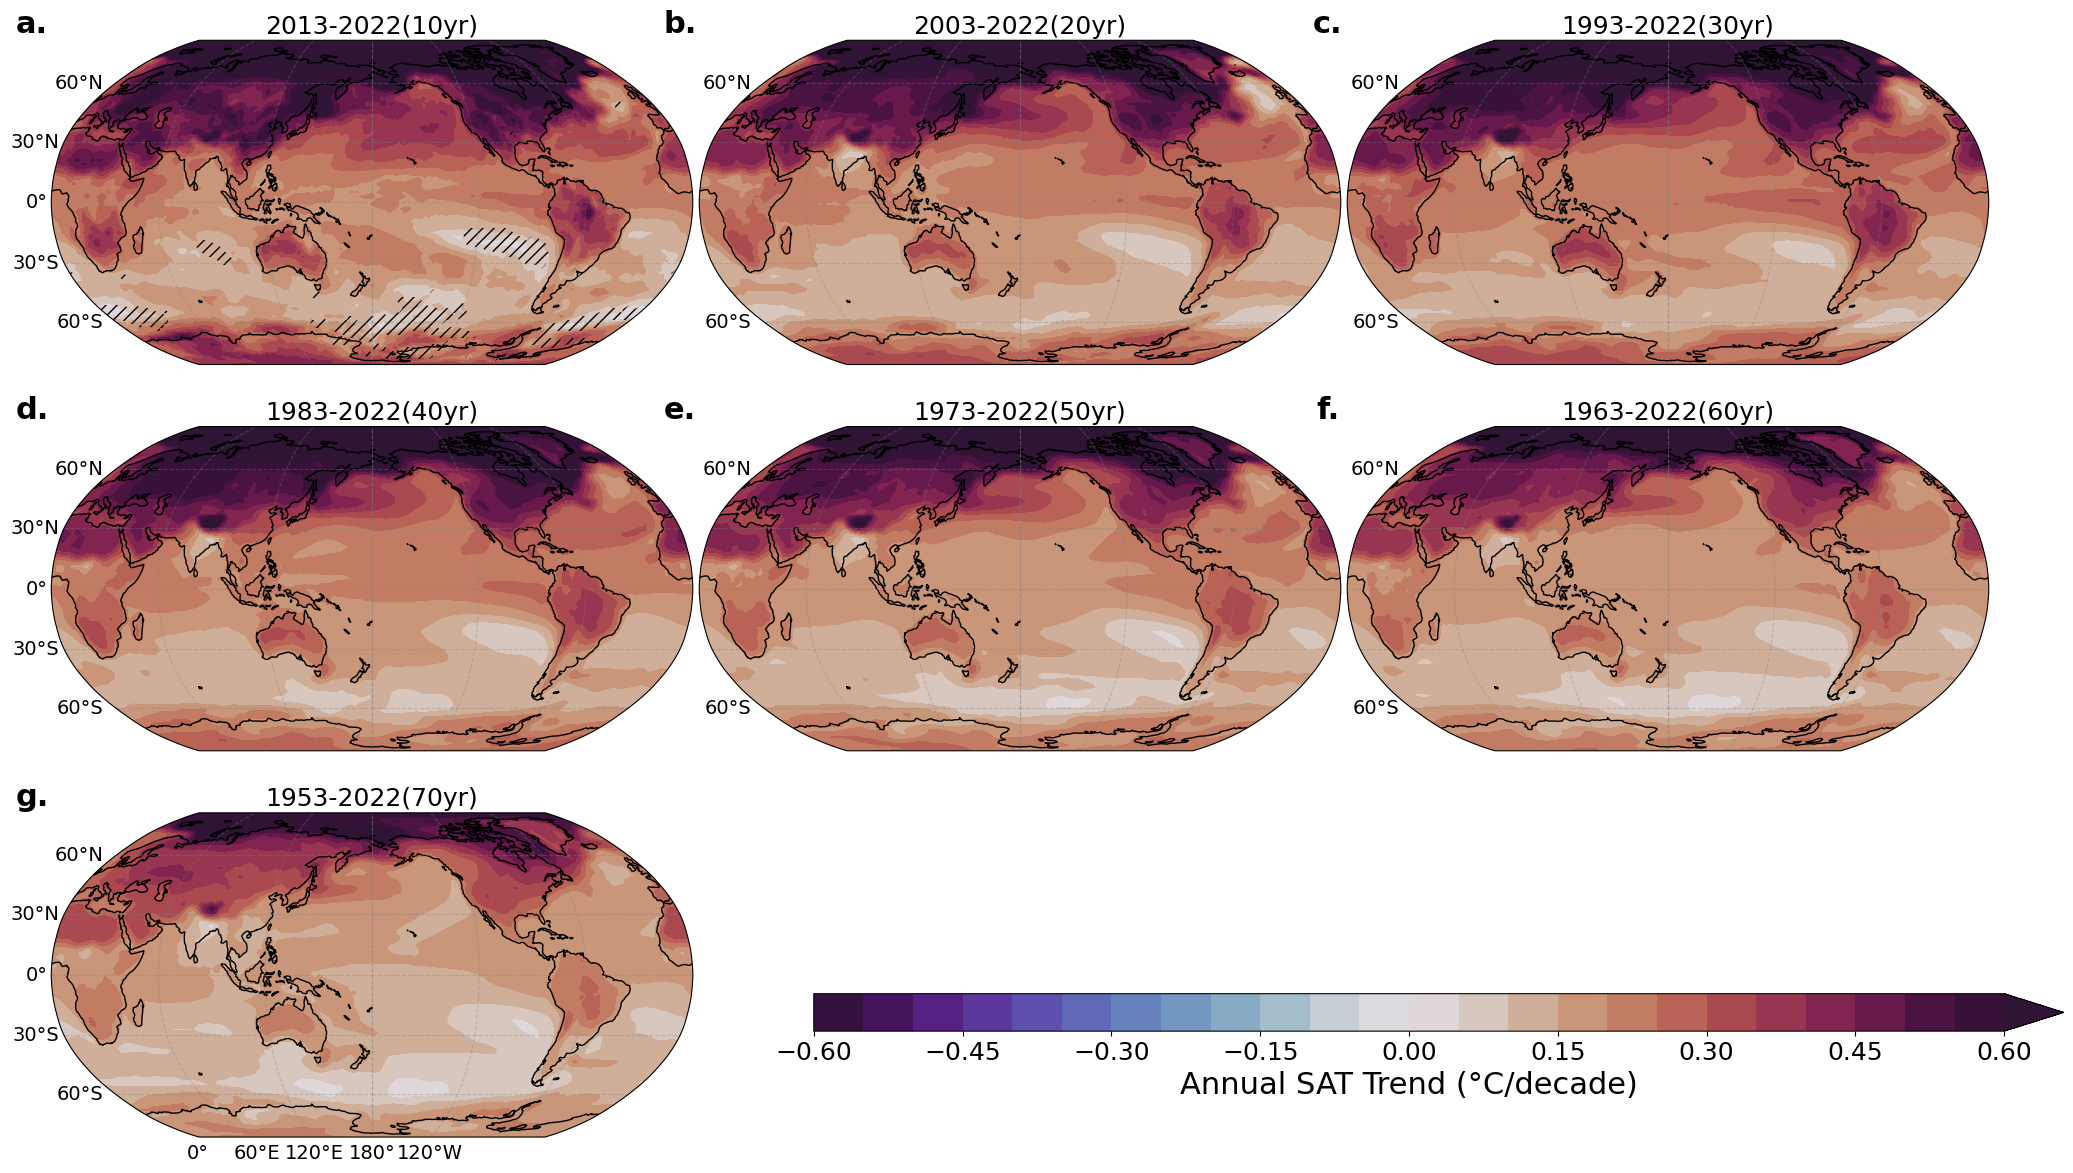

In [18]:
lat = MMEM_annual_tas_dict['10yr']['lat'].values
lon = MMEM_annual_tas_dict['10yr']['lon'].values
lat, lon 

titles = ["2013-2022(10yr)", "2003-2022(20yr)", "1993-2022(30yr)", "1983-2022(40yr)", "1973-2022(50yr)", "1963-2022(60yr)", "1953-2022(70yr)"]
titles_left = ["a.", "b.", "c.", "d.", "e.", "f.", "g."]

import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

# Define the GridSpec
fig = plt.figure(figsize=(25, 15))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], width_ratios=[1, 1, 1], wspace=0.01, hspace=0.01)

extend= 'max'
periods = ["10yr", "20yr", "30yr", "40yr", "50yr", "60yr", "70yr"]
for j, period in enumerate(periods):
    # Define the axes
    ax = fig.add_subplot(gs[j], projection=ccrs.Robinson(180))
    is_left = (j % 3 == 0)
    is_bottom_row = j >= (len(periods)//3)*3 
    
    trend_data = MMEM_annual_tas_trend_da[period]
    trend_with_cyclic, lon_with_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
    p_values = MMEM_annual_tas_p_value[period]
    p_values_with_cyclic, lon_with_cyclic = cutil.add_cyclic_point(p_values, coord=lon)
    levels = np.arange(-0.6, 0.65, 0.05)
    contour_obj = plot_trend_with_significance(trend_with_cyclic, lat, lon_with_cyclic, p_values_with_cyclic, 
                    GMST_p_values=None, levels=levels,extend=extend, cmap='twilight_shifted',
                    # cmap=mcolors.ListedColormap(palettable.cmocean.diverging.Balance_20.mpl_colors),
                    title=titles[j], ax=ax, show_xticks = is_bottom_row, show_yticks = is_left)
    ax.text(-0.03, 1.05, titles_left[j], fontsize=22,weight='bold', ha='center', va='center', rotation='horizontal', transform=ax.transAxes)

# Add horizontal colorbars
cbar_ax = fig.add_axes([0.43, 0.2, 0.5, 0.025])
cbar = plt.colorbar(contour_obj, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Annual SAT Trend (°C/decade)', fontsize=22)

plt.tight_layout()
fig.savefig('MMEM_simulated_trend_Pattern_variations.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
client.close()
scluster.close()